In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

# Paths
TRAIN_IMAGES = "/teamspace/studios/this_studio/cell_dataset/train/train_images"
TRAIN_MASKS  = "/teamspace/studios/this_studio/cell_dataset/train/train_masks"
TEST_IMAGES  = "/teamspace/studios/this_studio/cell_dataset/test/test_images"
MODEL_PATH   = "../models/unet_best.pth"

NUM_CLASSES  = 5
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Imports done!")
print(f"Device: {device}")

Imports done!
Device: cuda


In [2]:
# All helper functions needed from previous notebooks

COLOR_TO_CLASS = {
    (0,   0,   0):   0,  # Background
    (255, 255, 0):   1,  # Yellow Cell
    (255, 0,   0):   2,  # Red Cell
    (0,   255, 0):   3,  # Green Cell
    (0,   0,   255): 4,  # Blue Cell
}
CLASS_TO_COLOR = {v: k for k, v in COLOR_TO_CLASS.items()}
CLASS_NAMES    = ["Background", "Yellow Cell", "Red Cell", "Green Cell", "Blue Cell"]

def rgb_to_mask(mask_rgb):
    H, W, _ = mask_rgb.shape
    label_map = np.zeros((H, W), dtype=np.int64)
    for color, class_id in COLOR_TO_CLASS.items():
        match = np.all(mask_rgb == np.array(color), axis=-1)
        label_map[match] = class_id
    return label_map

def mask_to_rgb(label_map):
    H, W = label_map.shape
    rgb = np.zeros((H, W, 3), dtype=np.uint8)
    for class_id, color in CLASS_TO_COLOR.items():
        rgb[label_map == class_id] = color
    return rgb

def torchvision_random_crop_params(img, scale=(0.7, 1.0)):
    width, height = img.size
    area = height * width
    target_area = random.uniform(scale[0], scale[1]) * area
    aspect_ratio = width / height
    w = int(round((target_area * aspect_ratio) ** 0.5))
    h = int(round((target_area / aspect_ratio) ** 0.5))
    w = min(w, width)
    h = min(h, height)
    i = random.randint(0, height - h)
    j = random.randint(0, width  - w)
    return i, j, h, w

def augment(image, mask):
    if random.random() > 0.5:
        image = TF.hflip(image); mask = TF.hflip(mask)
    if random.random() > 0.5:
        image = TF.vflip(image); mask = TF.vflip(mask)
    angle = random.choice([0, 90, 180, 270])
    image = TF.rotate(image, angle); mask = TF.rotate(mask, angle)
    i, j, h, w = torchvision_random_crop_params(image, scale=(0.7, 1.0))
    image = TF.resized_crop(image, i, j, h, w, size=(512, 512),
                             interpolation=TF.InterpolationMode.BILINEAR)
    mask  = TF.resized_crop(mask,  i, j, h, w, size=(512, 512),
                             interpolation=TF.InterpolationMode.NEAREST)
    image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.8, 1.2))
    image = TF.adjust_contrast(image,   contrast_factor=random.uniform(0.8, 1.2))
    return image, mask

class CellSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, filenames, is_train=True):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.filenames = filenames
        self.is_train  = is_train
    def __len__(self):
        return len(self.filenames)
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        image = Image.open(os.path.join(self.image_dir, fname)).convert("RGB")
        mask  = Image.open(os.path.join(self.mask_dir,  fname)).convert("RGB")
        if self.is_train:
            image, mask = augment(image, mask)
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406],
                                    std= [0.229, 0.224, 0.225])
        mask  = np.array(mask)
        mask  = rgb_to_mask(mask)
        mask  = torch.from_numpy(mask).long()
        return image, mask

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout),
        )
    def forward(self, x): return self.block(x)

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(3,   64,  dropout=0.1)
        self.enc2 = ConvBlock(64,  128, dropout=0.1)
        self.enc3 = ConvBlock(128, 256, dropout=0.2)
        self.enc4 = ConvBlock(256, 512, dropout=0.2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        return self.pool(s4), [s1, s2, s3, s4]

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up3 = nn.ConvTranspose2d(512,  256, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose2d(256,  128, kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose2d(128,  64,  kernel_size=2, stride=2)
        self.dec4 = ConvBlock(1024, 512, dropout=0.2)
        self.dec3 = ConvBlock(512,  256, dropout=0.2)
        self.dec2 = ConvBlock(256,  128, dropout=0.1)
        self.dec1 = ConvBlock(128,  64,  dropout=0.1)
    def forward(self, x, skips):
        s1, s2, s3, s4 = skips
        x = self.up4(x); x = torch.cat([x, s4], dim=1); x = self.dec4(x)
        x = self.up3(x); x = torch.cat([x, s3], dim=1); x = self.dec3(x)
        x = self.up2(x); x = torch.cat([x, s2], dim=1); x = self.dec2(x)
        x = self.up1(x); x = torch.cat([x, s1], dim=1); x = self.dec1(x)
        return x

class UNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.encoder    = Encoder()
        self.bottleneck = ConvBlock(512, 1024, dropout=0.3)
        self.decoder    = Decoder()
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)
    def forward(self, x):
        x, skips = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        return self.final_conv(x)

print("✅ All helper functions ready!")

✅ All helper functions ready!


In [3]:
model = UNet(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()  # Disable dropout for evaluation

print(f"✅ Model loaded from {MODEL_PATH}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

✅ Model loaded from ../models/unet_best.pth
Total parameters: 31,037,893


In [4]:
all_images = sorted(os.listdir(TRAIN_IMAGES))
all_masks  = sorted(os.listdir(TRAIN_MASKS))

_, val_imgs, _, val_msks = train_test_split(
    all_images, all_masks,
    test_size=0.1,
    random_state=42  # must match training notebook
)

val_dataset = CellSegmentationDataset(
    TRAIN_IMAGES, TRAIN_MASKS, val_imgs, is_train=False
)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

print(f"✅ Validation set: {len(val_dataset)} images")
print(f"   Files: {val_imgs}")

✅ Validation set: 11 images
   Files: ['train_2_1.png', 'train_12_2.png', 'train_11_0.png', 'train_3_3.png', 'train_24_2.png', 'train_25_3.png', 'train_17_2.png', 'train_20_1.png', 'train_6_3.png', 'train_12_3.png', 'train_3_1.png']


In [5]:
def evaluate_per_class(model, loader, num_classes=5, smooth=1e-6):
    """
    Compute per-class IoU and Dice Score across the entire validation set.
    
    Unlike the training metrics which averaged across batches,
    this function accumulates pixel counts across ALL images first
    then computes metrics — giving a more accurate global score.
    """
    model.eval()

    # Accumulators for each class
    intersection = np.zeros(num_classes)
    union        = np.zeros(num_classes)
    pred_sum     = np.zeros(num_classes)
    target_sum   = np.zeros(num_classes)

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks  = masks.to(device)

            preds = model(images)
            preds = torch.argmax(preds, dim=1)  # (B, H, W)

            for cls in range(num_classes):
                pred_cls   = (preds == cls)
                target_cls = (masks == cls)

                intersection[cls] += (pred_cls & target_cls).sum().item()
                union[cls]        += (pred_cls | target_cls).sum().item()
                pred_sum[cls]     += pred_cls.sum().item()
                target_sum[cls]   += target_cls.sum().item()

    # Compute metrics per class
    iou_per_class  = (intersection + smooth) / (union + smooth)
    dice_per_class = (2 * intersection + smooth) / (pred_sum + target_sum + smooth)

    return iou_per_class, dice_per_class


iou_per_class, dice_per_class = evaluate_per_class(model, val_loader)

print("=" * 55)
print(f"{'Class':<18} {'IoU':>8} {'Dice':>8}")
print("=" * 55)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<18} {iou_per_class[i]:>8.4f} {dice_per_class[i]:>8.4f}")
print("-" * 55)
# Exclude background from mean — it would inflate the score
print(f"{'mIoU (no bg)':<18} {np.mean(iou_per_class[1:]):>8.4f}")
print(f"{'Dice (no bg)':<18} {np.mean(dice_per_class[1:]):>8.4f}")
print(f"{'mIoU (all)':<18} {np.mean(iou_per_class):>8.4f}")
print(f"{'Dice (all)':<18} {np.mean(dice_per_class):>8.4f}")
print("=" * 55)

Class                   IoU     Dice
Background           0.6463   0.7852
Yellow Cell          0.0008   0.0017
Red Cell             0.1999   0.3332
Green Cell           0.3533   0.5221
Blue Cell            0.1669   0.2860
-------------------------------------------------------
mIoU (no bg)         0.1802
Dice (no bg)         0.2858
mIoU (all)           0.2735
Dice (all)           0.3856


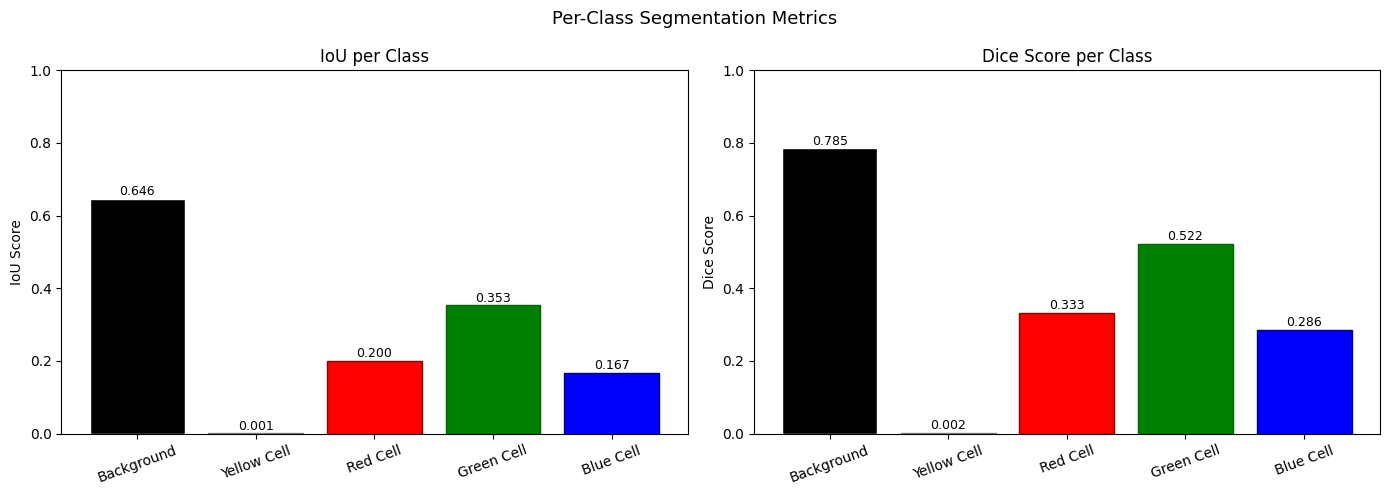

Saved to ../results/per_class_metrics.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Per-Class Segmentation Metrics", fontsize=13)

colors = ["black", "yellow", "red", "green", "blue"]
edge   = ["white", "gray", "darkred", "darkgreen", "darkblue"]

# IoU bar chart
axes[0].bar(CLASS_NAMES, iou_per_class, color=colors, edgecolor=edge)
axes[0].set_title("IoU per Class")
axes[0].set_ylabel("IoU Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(iou_per_class):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# Dice bar chart
axes[1].bar(CLASS_NAMES, dice_per_class, color=colors, edgecolor=edge)
axes[1].set_title("Dice Score per Class")
axes[1].set_ylabel("Dice Score")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(dice_per_class):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../results/per_class_metrics.png", dpi=150)
plt.show()
print("Saved to ../results/per_class_metrics.png")

In [ ]:
def denormalize(tensor):
    """
    Reverse the ImageNet normalization to display the image correctly.
    Without this, the image would look washed out and wrong colored.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Visualize predictions for 4 validation images
# Each row shows: Original Image | Ground Truth Mask | Predicted Mask
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
fig.suptitle("UNet Predictions vs Ground Truth", fontsize=14)

col_titles = ["Original Image", "Ground Truth", "Prediction"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight="bold")

model.eval()
with torch.no_grad():
    for i in range(4):
        # Load one validation image
        fname = val_imgs[i]
        image = Image.open(os.path.join(TRAIN_IMAGES, fname)).convert("RGB")
        mask  = Image.open(os.path.join(TRAIN_MASKS,  fname)).convert("RGB")

        # Preprocess image
        img_tensor = TF.to_tensor(image)
        img_tensor = TF.normalize(img_tensor,
                                  mean=[0.485, 0.456, 0.406],
                                  std= [0.229, 0.224, 0.225])

        # Run prediction
        # unsqueeze(0) adds batch dimension: (3,512,512) → (1,3,512,512)
        output = model(img_tensor.unsqueeze(0).to(device))
        pred   = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        # Convert prediction class IDs → RGB for visualization
        pred_rgb = mask_to_rgb(pred)

        # Column 1 — Original image
        axes[i, 0].imshow(image)
        axes[i, 0].set_ylabel(fname, fontsize=7)
        axes[i, 0].axis("off")

        # Column 2 — Ground truth mask
        axes[i, 1].imshow(mask)
        axes[i, 1].axis("off")

        # Column 3 — Model prediction
        axes[i, 2].imshow(pred_rgb)
        axes[i, 2].axis("off")

# Add color legend at the bottom
legend_elements = [
    mpatches.Patch(color="black",  label="Background"),
    mpatches.Patch(color="yellow", label="Yellow Cell"),
    mpatches.Patch(color="red",    label="Red Cell"),
    mpatches.Patch(color="green",  label="Green Cell"),
    mpatches.Patch(color="blue",   label="Blue Cell"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=5, fontsize=10, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("../results/predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to ../results/predictions.png")

In [ ]:
# Plot training history saved during training notebook
# If history dict is not available, we plot from saved values

# Paste your history values here from training output
train_losses = history["train_loss"]
val_losses   = history["val_loss"]
val_mious    = history["val_miou"]
val_dices    = history["val_dice"]
epochs       = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History", fontsize=13)

# Loss curves
axes[0].plot(epochs, train_losses, label="Train Loss", color="steelblue")
axes[0].plot(epochs, val_losses,   label="Val Loss",   color="orange")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# mIoU curve
axes[1].plot(epochs, val_mious, label="Val mIoU", color="green")
axes[1].set_title("Validation mIoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mIoU")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Dice Score curve
axes[2].plot(epochs, val_dices, label="Val Dice", color="red")
axes[2].set_title("Validation Dice Score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Dice Score")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/training_curves.png", dpi=150)
plt.show()
print("Saved to ../results/training_curves.png")